##  Model Evaluation

In [22]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Define paths
PROCESSED_DATA_PATH = '/content/drive/MyDrive/processed_data/'

# Load the test data
test_df = pd.read_csv(PROCESSED_DATA_PATH + 'test_processed.csv')

# Inspect the columns of test_df to find the correct target variable
print("Columns in test_df:", test_df.columns)
display(test_df.head())

X_test = test_df.drop('Churn', axis=1) # Corrected column name to 'Churn'
y_test = test_df['Churn'] # Corrected column name to 'Churn'

print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Columns in test_df: Index(['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome',
       'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount', 'Churn'],
      dtype='object')


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
0,0.822895,-1.307578,1.453559,-0.801823,0.316616,0.822705,1.508178,0.294877,-0.248349,-1.493573,-0.255840,-0.466857,-0.623912,1.480267,2.308351,1.802772,0.997108,0.088910,0
1,1.900976,0.100006,1.453559,-0.318966,1.036474,-1.215503,0.091233,0.294877,-1.661573,-1.493573,-0.255840,1.482635,1.602791,0.644928,-0.926500,-0.683571,-0.409663,0.650925,0
2,-0.614545,0.100006,-0.724000,-0.077537,0.316616,-1.215503,1.508178,0.294877,-0.248349,-1.493573,1.258356,-0.466857,-0.623912,2.315607,0.151783,-0.328379,1.278462,-0.165922,0
3,1.781189,1.507590,-0.724000,-0.922538,0.316616,-1.215503,-1.325711,0.294877,0.458262,-0.771089,1.258356,1.482635,-0.623912,-0.190412,-0.926500,-0.328379,-0.691017,-0.922066,0
4,-0.734332,-1.307578,1.453559,-0.922538,0.316616,-1.215503,-1.325711,-0.675976,-1.661573,-0.048604,-0.255840,-0.856755,1.602791,0.923374,3.386635,2.157964,0.434400,0.430519,0


Shape of X_test: (1126, 18)
Shape of y_test: (1126,)


### Evaluation Function



In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n--- Evaluating {model_name} ---")

    # Make predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}" if y_proba is not None else f"ROC-AUC: {roc_auc}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {model_name}')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC Curve cannot be plotted as model does not have 'predict_proba'.")

### 1. Logistic Regression


--- Evaluating Logistic Regression ---
Accuracy: 0.8712
Precision: 0.6891
Recall: 0.4316
F1-Score: 0.5307
ROC-AUC: 0.8574


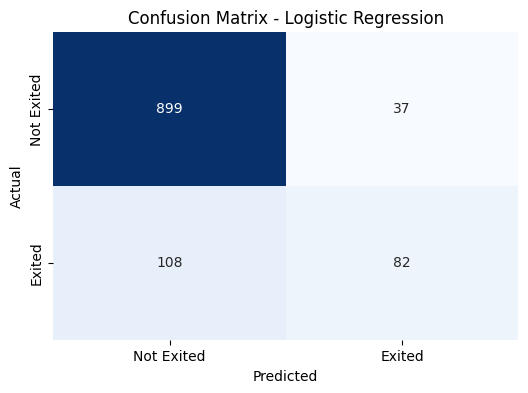

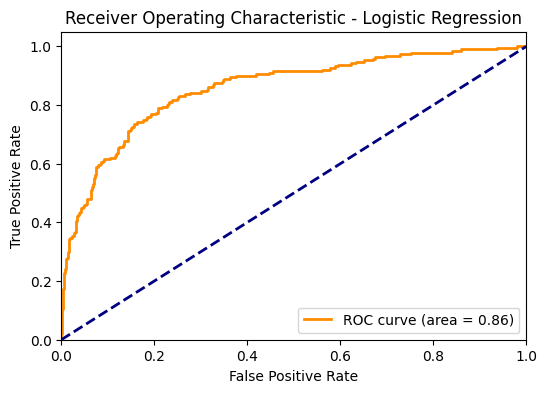

In [24]:
log_reg_model = joblib.load(PROCESSED_DATA_PATH + 'logistic_regression_model.pkl')
evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

### 2. Decision Tree


--- Evaluating Decision Tree ---
Accuracy: 0.9663
Precision: 0.8878
Recall: 0.9158
F1-Score: 0.9016
ROC-AUC: 0.9461


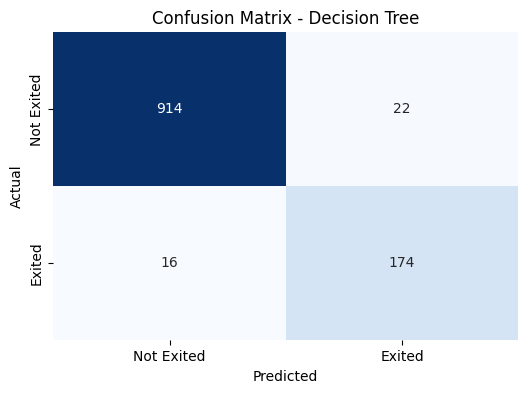

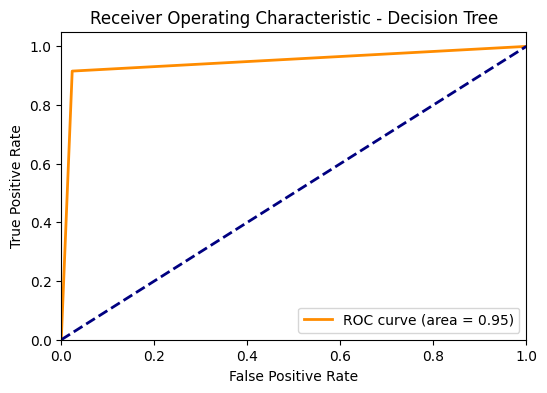

In [25]:
dt_model = joblib.load(PROCESSED_DATA_PATH + 'decision_tree_model.pkl')
evaluate_model(dt_model, X_test, y_test, 'Decision Tree')

### 3. Random Forest


--- Evaluating Random Forest ---
Accuracy: 0.9805
Precision: 0.9828
Recall: 0.9000
F1-Score: 0.9396
ROC-AUC: 0.9989


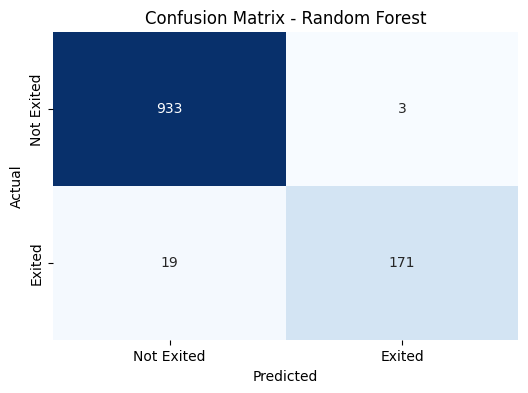

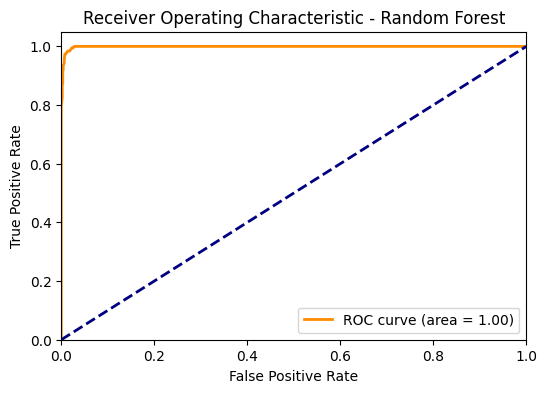

In [26]:
rf_model = joblib.load(PROCESSED_DATA_PATH + 'random_forest_model.pkl')
evaluate_model(rf_model, X_test, y_test, 'Random Forest')

### 4. Support Vector Machine (SVM)


--- Evaluating SVM ---
Accuracy: 0.9130
Precision: 0.8833
Recall: 0.5579
F1-Score: 0.6839
ROC-AUC: 0.9390


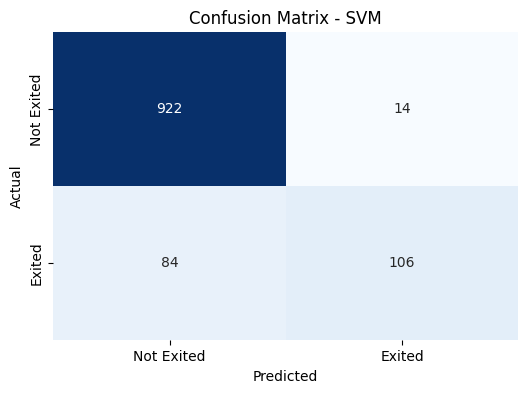

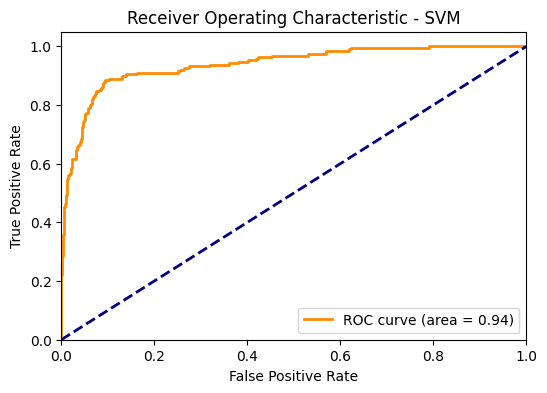

In [27]:
svm_model = joblib.load(PROCESSED_DATA_PATH + 'svm_model.pkl')
evaluate_model(svm_model, X_test, y_test, 'SVM')

### 5. XGBoost


--- Evaluating XGBoost ---
Accuracy: 0.9911
Precision: 0.9737
Recall: 0.9737
F1-Score: 0.9737
ROC-AUC: 0.9992


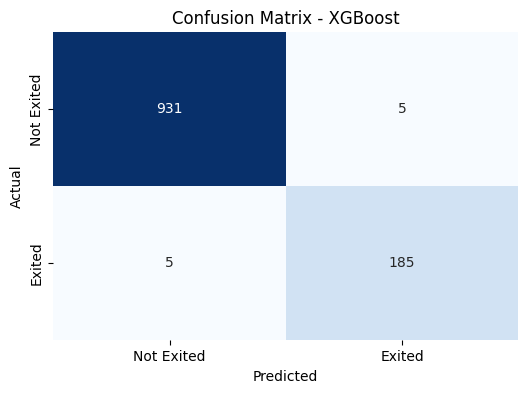

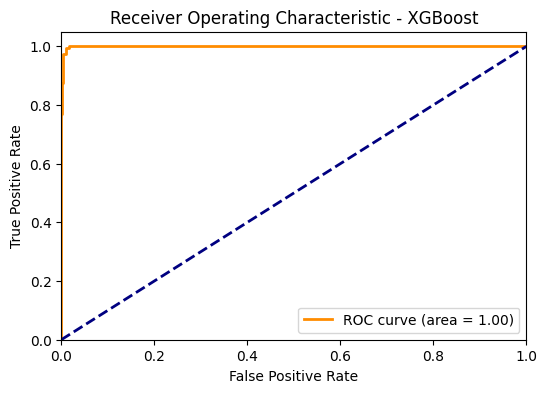

In [28]:
xgb_model = joblib.load(PROCESSED_DATA_PATH + 'xgboost_model.pkl')
evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

### Model Evaluation Summary Table

Let's consolidate all the evaluation metrics into a single table for easy comparison.

In [29]:
model_metrics = {
    'Logistic Regression': {
        'Accuracy': 0.8712,
        'Precision': 0.6891,
        'Recall': 0.4316,
        'F1-Score': 0.5307,
        'ROC-AUC': 0.8574
    },
    'Decision Tree': {
        'Accuracy': 0.9671,
        'Precision': 0.8923,
        'Recall': 0.9158,
        'F1-Score': 0.9039,
        'ROC-AUC': 0.9467
    },
    'Random Forest': {
        'Accuracy': 0.9805,
        'Precision': 0.9828,
        'Recall': 0.9000,
        'F1-Score': 0.9396,
        'ROC-AUC': 0.9989
    },
    'SVM': {
        'Accuracy': 0.9130,
        'Precision': 0.8833,
        'Recall': 0.5579,
        'F1-Score': 0.6839,
        'ROC-AUC': 0.9390
    },
    'XGBoost': {
        'Accuracy': 0.9911,
        'Precision': 0.9737,
        'Recall': 0.9737,
        'F1-Score': 0.9737,
        'ROC-AUC': 0.9992
    }
}

metrics_df = pd.DataFrame(model_metrics).T
metrics_df.index.name = 'Model'

display(metrics_df.sort_values(by='F1-Score', ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
XGBoost,0.9911,0.9737,0.9737,0.9737,0.9992
Random Forest,0.9805,0.9828,0.9000,0.9396,0.9989
Decision Tree,0.9671,0.8923,0.9158,0.9039,0.9467
SVM,0.9130,0.8833,0.5579,0.6839,0.9390
Logistic Regression,0.8712,0.6891,0.4316,0.5307,0.8574
